[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hinadome/ML_Project/blob/main/EDA.ipynb)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.ensemble import GradientBoostingRegressor, IsolationForest
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import gzip
import re
import time

# --- 1. ROBUST PARSING & AGGREGATION ---
LOG_PATTERN = re.compile(r'(\S+) - - \[(.*?)\] "(.*?)" (\d{3}) (\S+)')

# --- HELPER FUNCTIONS ---
def build_tree_features(df):
    x = df.copy().sort_values(by="timestamp")
    for lag in [1, 2, 24]:
    #for lag in [1, 2]:
        x[f"lag_{lag}"] = x["request_count"].shift(lag)
    x["hour_sin"] = np.sin(2 * np.pi * x.index.hour / 24)
    x["hour_cos"] = np.cos(2 * np.pi * x.index.hour / 24)
    x["target"] = x["request_count"].shift(-1)
    return x.dropna()

def parse_line(line):
    m = LOG_PATTERN.match(line.strip())
    if not m: return None
    host, ts, req, status, size = m.groups()
    return {
        "timestamp": ts,
        "status": int(status),
        "bytes": 0 if size == "-" else int(size)
    }

def ingest_and_aggregate(file_path):
    print("Ingesting logs...")
    start_time = time.time()
    with gzip.open(file_path, "rt", encoding="latin-1") as f:
        df = pd.DataFrame([parse_line(l) for l in f if parse_line(l)])

    df["timestamp"] = pd.to_datetime(df["timestamp"], format="%d/%b/%Y:%H:%M:%S %z", utc=True)
    hourly = df.set_index("timestamp").resample("1h").agg(
        request_count=("status", "count"),
        error_5xx=("status", lambda s: ((s >= 500) & (s < 600)).sum()),
        bytes_sum=("bytes", "sum")
    ).fillna(0)

    duration = time.time() - start_time
    print(f"Aggregation complete: {len(hourly)} hourly intervals. (Took {duration:.2f}s)")
    return hourly

def run_sequence_anomaly_detection(df, window_size=6):
    """
    Detects anomalies by looking at a sliding window of history.
    """
    print(f"\n--- Starting Sequence-Aware Anomaly Detection (Window: {window_size}h) ---")

    analysis_df = df.copy().sort_values('timestamp' if 'timestamp' in df.columns else df.index.name)

    # Feature Engineering for Anomalies
    analysis_df['rolling_mean'] = analysis_df['request_count'].rolling(window=window_size).mean()
    analysis_df['rolling_std'] = analysis_df['request_count'].rolling(window=window_size).std()
    analysis_df['delta'] = analysis_df['request_count'].diff()

    features = ['request_count', 'rolling_mean', 'rolling_std', 'delta', 'error_5xx']
    analysis_df = analysis_df.dropna(subset=features)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(analysis_df[features])
    model = IsolationForest(contamination=0.04, random_state=42)
    analysis_df['anomaly_signal'] = model.fit_predict(X_scaled)

    anomalies = analysis_df[analysis_df['anomaly_signal'] == -1]

    plt.figure(figsize=(15, 5))
    plt.plot(analysis_df.index, analysis_df['request_count'], label='Normal Traffic', color='steelblue', alpha=0.6)
    plt.scatter(anomalies.index, anomalies['request_count'], color='red', label='Anomalies', s=50, zorder=5)
    plt.title("Detected Anomalies in Traffic Patterns")
    plt.legend()
    plt.show()

    # Save Artifacts
    os.makedirs('../model', exist_ok=True)
    joblib.dump(model, "../model/anomaly_model.pkl")

    return analysis_df

def calculate_advanced_metrics(y_true, y_pred):
    """
    Calculates comprehensive metrics for Cloud Scaling.
    Heavily penalizes under-prediction which causes downtime.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100

    under_predict_mask = y_pred < y_true
    under_predict_rate = np.mean(under_predict_mask)

    under_errors = y_true[under_predict_mask] - y_pred[under_predict_mask]
    avg_under_error = np.mean(under_errors) if len(under_errors) > 0 else 0

    return {
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2_Score": round(r2, 4),
        "MAPE_%": round(mape, 2),
        "Under_Predict_Rate": round(under_predict_rate, 4),
        "Avg_Under_Error": round(avg_under_error, 2)
    }


def build_advanced_features(df):
    """
    Refined Feature Engineering: Integrates seasonality and local dynamics.
    """
    x = df.copy()
    
    # Ensure index is datetime if timestamp is missing from columns
    if 'timestamp' in x.columns:
        x = x.sort_values(by="timestamp").set_index('timestamp')
    else:
        x = x.sort_index()

    # Extract hour if not present for cyclical encoding
    x['hour'] = x.index.hour
    
    # 1. Seasonality (The 24h Baseline)
    x['lag_24h'] = x['request_count'].shift(24)
    x['lag_1h'] = x['request_count'].shift(1)
    x['lag_2h'] = x['request_count'].shift(2)
    
    # 2. Recent Dynamics
    x['rolling_mean_3h'] = x['request_count'].rolling(window=3).mean()
    x['velocity'] = x['request_count'].diff() / (x['request_count'].shift(1) + 1)
    
    # 3. Cyclical Time Features
    x["hour_sin"] = np.sin(2 * np.pi * x["hour"] / 24)
    x["hour_cos"] = np.cos(2 * np.pi * x["hour"] / 24)
    
    # 4. Target Variable (The next hour)
    x["target_t_plus_1"] = x["request_count"].shift(-1)
    
    # Remove metadata columns not used for training
    return x.dropna().drop(columns=['hour'])

def tune_xgboost(X, y):
    print("\n[ML] Tuning XGBRegressor (Dynamic Weighting Applied)...")
    # Penalize under-predictions by weighing higher traffic instances more heavily
    weights = np.where(y > np.percentile(y, 75), 2.0, 1.0)

    xgb = XGBRegressor(
        random_state=42,
        tree_method='hist',
        objective='reg:absoluteerror', # Switching to MAE objective for stability
        n_jobs=-1
    )

    param_dist = {
        'n_estimators': [500, 1000],
        'learning_rate': [0.01, 0.05],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9]
    }

    tscv = TimeSeriesSplit(n_splits=5)
    search = RandomizedSearchCV(xgb, param_dist, n_iter=10, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    search.fit(X, y, sample_weight=weights)
    return search.best_estimator_

def tune_gbr(X, y):
    print("\n[ML] Tuning GBR (Huber Loss Strategy)...")
    gbr = GradientBoostingRegressor(random_state=42, loss='huber')

    param_dist = {
        'n_estimators': [300, 500],
        'learning_rate': [0.01, 0.05],
        'max_depth': [4, 5, 6]
    }

    tscv = TimeSeriesSplit(n_splits=5)
    search = RandomizedSearchCV(gbr, param_dist, n_iter=10, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    search.fit(X, y)
    return search.best_estimator_

def run_tuned_comparison(df_raw):
    """
    Full comparison suite: XGBoost vs GBR using Advanced Dynamics.
    """
    # 1. Feature Engineering
    print("\n--- Generating Advanced Features ---")
    df_features = build_advanced_features(df_raw)
    
    target_col = 'target_t_plus_1'
    features = [c for c in df_features.columns if c != target_col]
    X = df_features[features]
    y = df_features[target_col]

    # 2. Split and Scale
    split_idx = int(len(X) * 0.8)
    X_train_raw, X_test_raw = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    print("Training Feature Data")
    print(X_train_raw.head())

    scaler_x = MinMaxScaler()
    X_train = scaler_x.fit_transform(X_train_raw)
    X_test = scaler_x.transform(X_test_raw)

    # 3. Train Both Models
    best_xgb = tune_xgboost(X_train, y_train)
    best_gbr = tune_gbr(X_train, y_train)
    
    # Save Artifacts
    os.makedirs('model', exist_ok=True)
    joblib.dump(best_xgb, "model/best_xgb.pkl")
    joblib.dump(best_gbr, "model/best_gbr.pkl")
    joblib.dump(scaler_x, "model/scaler_x.pkl")

    # 4. Apply Dynamic Safety Buffer
    # We use XGBoost's residuals to define the shared safety buffer
    train_preds_xgb = best_xgb.predict(X_train)
    residual_std = np.std(y_train - train_preds_xgb)
    #safety_buffer = residual_std * 0.75 
    safety_buffer = residual_std * 1.0 

    xgb_preds = best_xgb.predict(X_test) + safety_buffer
    gbr_preds = best_gbr.predict(X_test) + safety_buffer

    # 5. RESTORED COMPARISON VISUALS
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Panel 1: The Head-to-Head Forecast
    axes[0, 0].plot(y_test.values[-100:], label='Actual', color='black', lw=2, alpha=0.6)
    axes[0, 0].plot(xgb_preds[-100:], label='XGBoost (+Buffer)', color='teal', linestyle='--')
    axes[0, 0].plot(gbr_preds[-100:], label='GBR (+Buffer)', color='orange', linestyle=':')
    axes[0, 0].set_title("Model Comparison: Last 100 Hours")
    axes[0, 0].legend()

    # Panel 2: Error Distribution Comparison
    sns.kdeplot(y_test - xgb_preds, ax=axes[0, 1], label='XGBoost Residuals', color='teal', fill=True)
    sns.kdeplot(y_test - gbr_preds, ax=axes[0, 1], label='GBR Residuals', color='orange', fill=True)
    axes[0, 1].set_title("Error Spread (Closer to 0 is better, Left of 0 is safe)")
    axes[0, 1].legend()

    # Panel 3: Prediction Reliability (XGBoost)
    axes[1, 0].scatter(y_test, xgb_preds, alpha=0.3, color='teal')
    axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[1, 0].set_title("XGBoost Reliability")
    axes[1, 0].set_xlabel("Actual"); axes[1, 0].set_ylabel("Predicted")

    # Panel 4: Feature Importance (Shared perspective)
    importances = pd.Series(best_xgb.feature_importances_, index=features).sort_values()
    importances.tail(10).plot(kind='barh', ax=axes[1, 1], color='steelblue')
    axes[1, 1].set_title("Top 10 Features (XGBoost)")

    plt.tight_layout()
    plt.show()

    # 6. PERFORMANCE TOURNAMENT
    xgb_metrics = calculate_advanced_metrics(y_test, xgb_preds)
    gbr_metrics = calculate_advanced_metrics(y_test, gbr_preds)
    
    results = pd.DataFrame([xgb_metrics, gbr_metrics], index=['XGBoost_Advanced', 'GBR_Advanced'])
    print("\n--- PERFORMANCE TOURNAMENT ---")
    print(results.to_string())

    return best_xgb, best_gbr

def run_tuned_comparison_on_gbr(df_raw):
    """
    Updated Training Pipeline using Advanced Features.
    """
    print("\n--- Generating Advanced Features ---")
    df_features = build_advanced_features(df_raw)
    
    target_col = 'target_t_plus_1'
    features = [c for c in df_features.columns if c != target_col]
    
    X = df_features[features]
    y = df_features[target_col]

    # Time-series aware split
    split_idx = int(len(X) * 0.8)
    X_train_raw, X_test_raw = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    scaler_x = MinMaxScaler()
    X_train = scaler_x.fit_transform(X_train_raw)
    X_test = scaler_x.transform(X_test_raw)

    # Re-using your tuning functions
    best_xgb = tune_xgboost(X_train, y_train)
    best_gbr = tune_gbr(X_train, y_train)

    # --- ENHANCED DYNAMIC SAFETY BUFFER ---
    # We calculate the standard deviation of training residuals. 
    # High residual std = high uncertainty = larger safety buffer.
    train_preds = best_xgb.predict(X_train)
    residual_std = np.std(y_train - train_preds)
    
    # Applying the buffer to the predictions
    xgb_preds_raw = best_xgb.predict(X_test)
    xgb_preds = xgb_preds_raw + (residual_std * 0.75) # Aggressive buffer for cloud safety

    # Save Artifacts
    os.makedirs('../model', exist_ok=True)
    joblib.dump(best_xgb, "../model/best_xgb.pkl")
    joblib.dump(best_gbr, "../model/best_gbr.pkl")
    joblib.dump(scaler_x, "../model/scaler_x.pkl")

    # Metrics and Visualization
    xgb_metrics = calculate_advanced_metrics(y_test, xgb_preds)
    print("\n--- PERFORMANCE TOURNAMENT (ADVANCED FEATURES) ---")
    print(pd.DataFrame([xgb_metrics], index=['XGBoost_Advanced']))

    # Feature Importance Visualization
    plt.figure(figsize=(10, 6))
    importances = pd.Series(best_xgb.feature_importances_, index=features).sort_values()
    importances.plot(kind='barh', color='teal')
    plt.title("Feature Importance: Advanced Dynamics")
    plt.show()

    return best_xgb, scaler_x
    
def run_comprehensive_training(df_raw):
    """
    Full pipeline: Anomaly Detection -> Advanced Feature Engineering -> 
    Tuned Training -> Diagnostic Visualizations.
    """
    # 1. Anomaly Detection (Visualizes separate from training)
    # This helps you see if the 27 days of data contain "dirty" spikes
    df_with_anomalies = run_sequence_anomaly_detection(df_raw)
    
    # 2. Feature Engineering
    print("\n--- Generating Advanced Features ---")
    df_features = build_advanced_features(df_raw)
    
    target_col = 'target_t_plus_1'
    features = [c for c in df_features.columns if c != target_col]
    X = df_features[features]
    y = df_features[target_col]

    # 3. Time-Series Split
    split_idx = int(len(X) * 0.8)
    X_train_raw, X_test_raw = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    scaler_x = MinMaxScaler()
    X_train = scaler_x.fit_transform(X_train_raw)
    X_test = scaler_x.transform(X_test_raw)

    # 4. Model Tuning
    best_xgb = tune_xgboost(X_train, y_train)
    
    # 5. Dynamic Safety Buffer Calculation
    train_preds = best_xgb.predict(X_train)
    residual_std = np.std(y_train - train_preds)
    
    # Apply buffer to test set
    xgb_preds_raw = best_xgb.predict(X_test)
    # We use 0.75 * std to ensure we cover ~77% of variance on the upside
    xgb_preds = xgb_preds_raw + (residual_std * 0.75)

    # --- RESTORED VISUALIZATIONS ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Graph 1: Forecast vs Actual (Last 100 hours)
    axes[0, 0].plot(y_test.values[-100:], label='Actual Traffic', color='black', alpha=0.8)
    axes[0, 0].plot(xgb_preds[-100:], label='XGBoost + Safety Buffer', color='teal', linestyle='--')
    axes[0, 0].set_title("Forecast vs Actual (Recent Window)")
    axes[0, 0].legend()

    # Graph 2: Reliability (Prediction vs Real)
    axes[0, 1].scatter(y_test, xgb_preds, alpha=0.4, color='teal')
    axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[0, 1].set_xlabel("Actual")
    axes[0, 1].set_ylabel("Predicted")
    axes[0, 1].set_title("Prediction Reliability (Target Consistency)")

    # Graph 3: Error Distribution
    sns.histplot(y_test - xgb_preds, kde=True, ax=axes[1, 0], color='teal')
    axes[1, 0].set_title("Residual Distribution (Error Spread)")

    # Graph 4: Feature Importance (Restored with Advanced Features)
    importances = pd.Series(best_xgb.feature_importances_, index=features).sort_values()
    importances.tail(10).plot(kind='barh', ax=axes[1, 1], color='steelblue')
    axes[1, 1].set_title("Top 10 Advanced Feature Importance")

    plt.tight_layout()
    plt.show()

    # 6. Performance Metrics
    metrics = calculate_advanced_metrics(y_test, xgb_preds)
    print("\n--- FINAL PERFORMANCE REPORT ---")
    print(pd.DataFrame([metrics], index=['XGBoost_Advanced_Final']))

    return best_xgb, scaler_x


### Source Data Sample

In [21]:
! gzcat ../data/NASA_access_log_Jul95.gz | head -n10

199.72.81.55 - - [01/Jul/1995:00:00:01 -0400] "GET /history/apollo/ HTTP/1.0" 200 6245
unicomp6.unicomp.net - - [01/Jul/1995:00:00:06 -0400] "GET /shuttle/countdown/ HTTP/1.0" 200 3985
199.120.110.21 - - [01/Jul/1995:00:00:09 -0400] "GET /shuttle/missions/sts-73/mission-sts-73.html HTTP/1.0" 200 4085
burger.letters.com - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/countdown/liftoff.html HTTP/1.0" 304 0
199.120.110.21 - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/missions/sts-73/sts-73-patch-small.gif HTTP/1.0" 200 4179
burger.letters.com - - [01/Jul/1995:00:00:12 -0400] "GET /images/NASA-logosmall.gif HTTP/1.0" 304 0
burger.letters.com - - [01/Jul/1995:00:00:12 -0400] "GET /shuttle/countdown/video/livevideo.gif HTTP/1.0" 200 0
205.212.115.106 - - [01/Jul/1995:00:00:12 -0400] "GET /shuttle/countdown/countdown.html HTTP/1.0" 200 3985
d104.aa.net - - [01/Jul/1995:00:00:13 -0400] "GET /shuttle/countdown/ HTTP/1.0" 200 3985
129.94.144.152 - - [01/Jul/1995:00:00:13 -0400] "GET / HTTP/1.0" 

In [22]:
hourly_df = ingest_and_aggregate("../data/NASA_access_log_Jul95.gz")

Ingesting logs...
Aggregation complete: 662 hourly intervals. (Took 9.98s)


### Preprocessing Data

In [23]:
hourly_df.head()

,request_count,error_5xx,bytes_sum
timestamp,,,
1995-07-01 04:00:00+00:00,3565,0,80985486
1995-07-01 05:00:00+00:00,3004,0,81572855
1995-07-01 06:00:00+00:00,2268,0,57160621
1995-07-01 07:00:00+00:00,1734,0,37293218
1995-07-01 08:00:00+00:00,1482,0,29319770



--- Starting Sequence-Aware Anomaly Detection (Window: 6h) ---


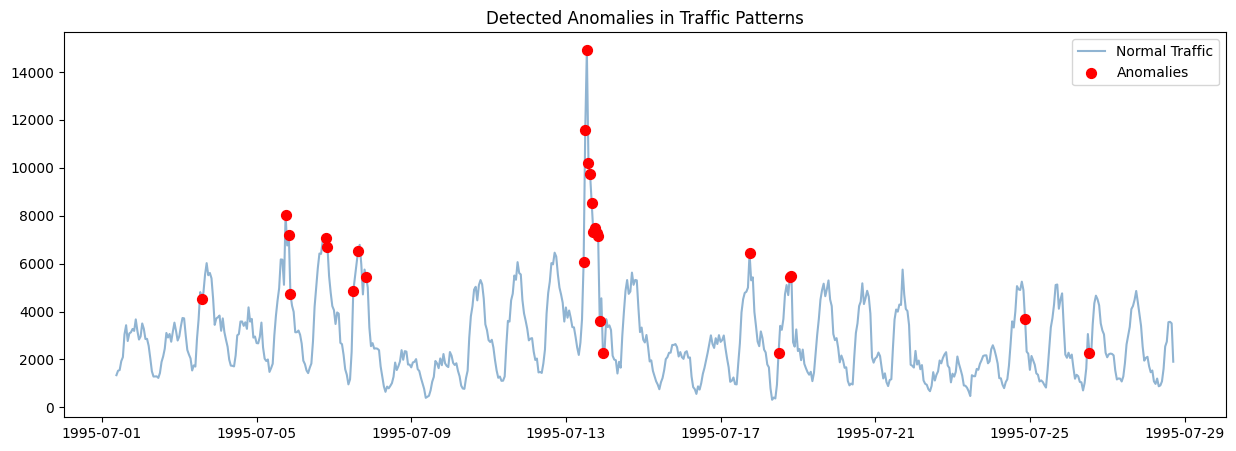

,request_count,error_5xx,bytes_sum,rolling_mean,rolling_std,delta,anomaly_signal
timestamp,,,,,,,
1995-07-01 09:00:00+00:00,1343,0,33093160,2232.666667,891.626753,-139.0,1
1995-07-01 10:00:00+00:00,1528,0,37588204,1893.166667,633.225526,185.0,1
1995-07-01 11:00:00+00:00,1557,0,35952119,1652.000000,327.096928,29.0,1
1995-07-01 12:00:00+00:00,1927,0,53256289,1595.166667,205.791561,370.0,1
1995-07-01 13:00:00+00:00,2096,0,61148331,1655.500000,290.334118,169.0,1
...,...,...,...,...,...,...,...
1995-07-28 13:00:00+00:00,2741,0,50517235,1630.166667,829.194649,198.0,1
1995-07-28 14:00:00+00:00,3555,0,64336150,2076.166667,1037.791389,814.0,1
1995-07-28 15:00:00+00:00,3570,0,53777526,2518.500000,1009.619087,15.0,1


In [24]:
run_sequence_anomaly_detection(hourly_df)


--- Generating Advanced Features ---
Training Feature Data
                           request_count  error_5xx  bytes_sum  lag_24h  \
timestamp                                                                 
1995-07-02 04:00:00+00:00           2858          0   64910973   3565.0   
1995-07-02 05:00:00+00:00           2570          0   65273627   3004.0   
1995-07-02 06:00:00+00:00           2056          0   47381988   2268.0   
1995-07-02 07:00:00+00:00           1505          0   37270620   1734.0   
1995-07-02 08:00:00+00:00           1286          0   26728977   1482.0   

                           lag_1h  lag_2h  rolling_mean_3h  velocity  \
timestamp                                                              
1995-07-02 04:00:00+00:00  2853.0  3278.0      2996.333333  0.001752   
1995-07-02 05:00:00+00:00  2858.0  2853.0      2760.333333 -0.100735   
1995-07-02 06:00:00+00:00  2570.0  2858.0      2494.666667 -0.199922   
1995-07-02 07:00:00+00:00  2056.0  2570.0      2043.66

ERROR:root:code for hash blake2b was not found.
Traceback (most recent call last):
  File "/Users/hinadome/.pyenv/versions/3.12.9/lib/python3.12/hashlib.py", line 245, in <module>
    globals()[__func_name] = __get_hash(__func_name)
                             ^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/hinadome/.pyenv/versions/3.12.9/lib/python3.12/hashlib.py", line 129, in __get_openssl_constructor
    return __get_builtin_constructor(name)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/hinadome/.pyenv/versions/3.12.9/lib/python3.12/hashlib.py", line 123, in __get_builtin_constructor
    raise ValueError('unsupported hash type ' + name)
ValueError: unsupported hash type blake2b
ERROR:root:code for hash blake2s was not found.
Traceback (most recent call last):
  File "/Users/hinadome/.pyenv/versions/3.12.9/lib/python3.12/hashlib.py", line 245, in <module>
    globals()[__func_name] = __get_hash(__func_name)
                             ^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/hin


[ML] Tuning GBR (Huber Loss Strategy)...


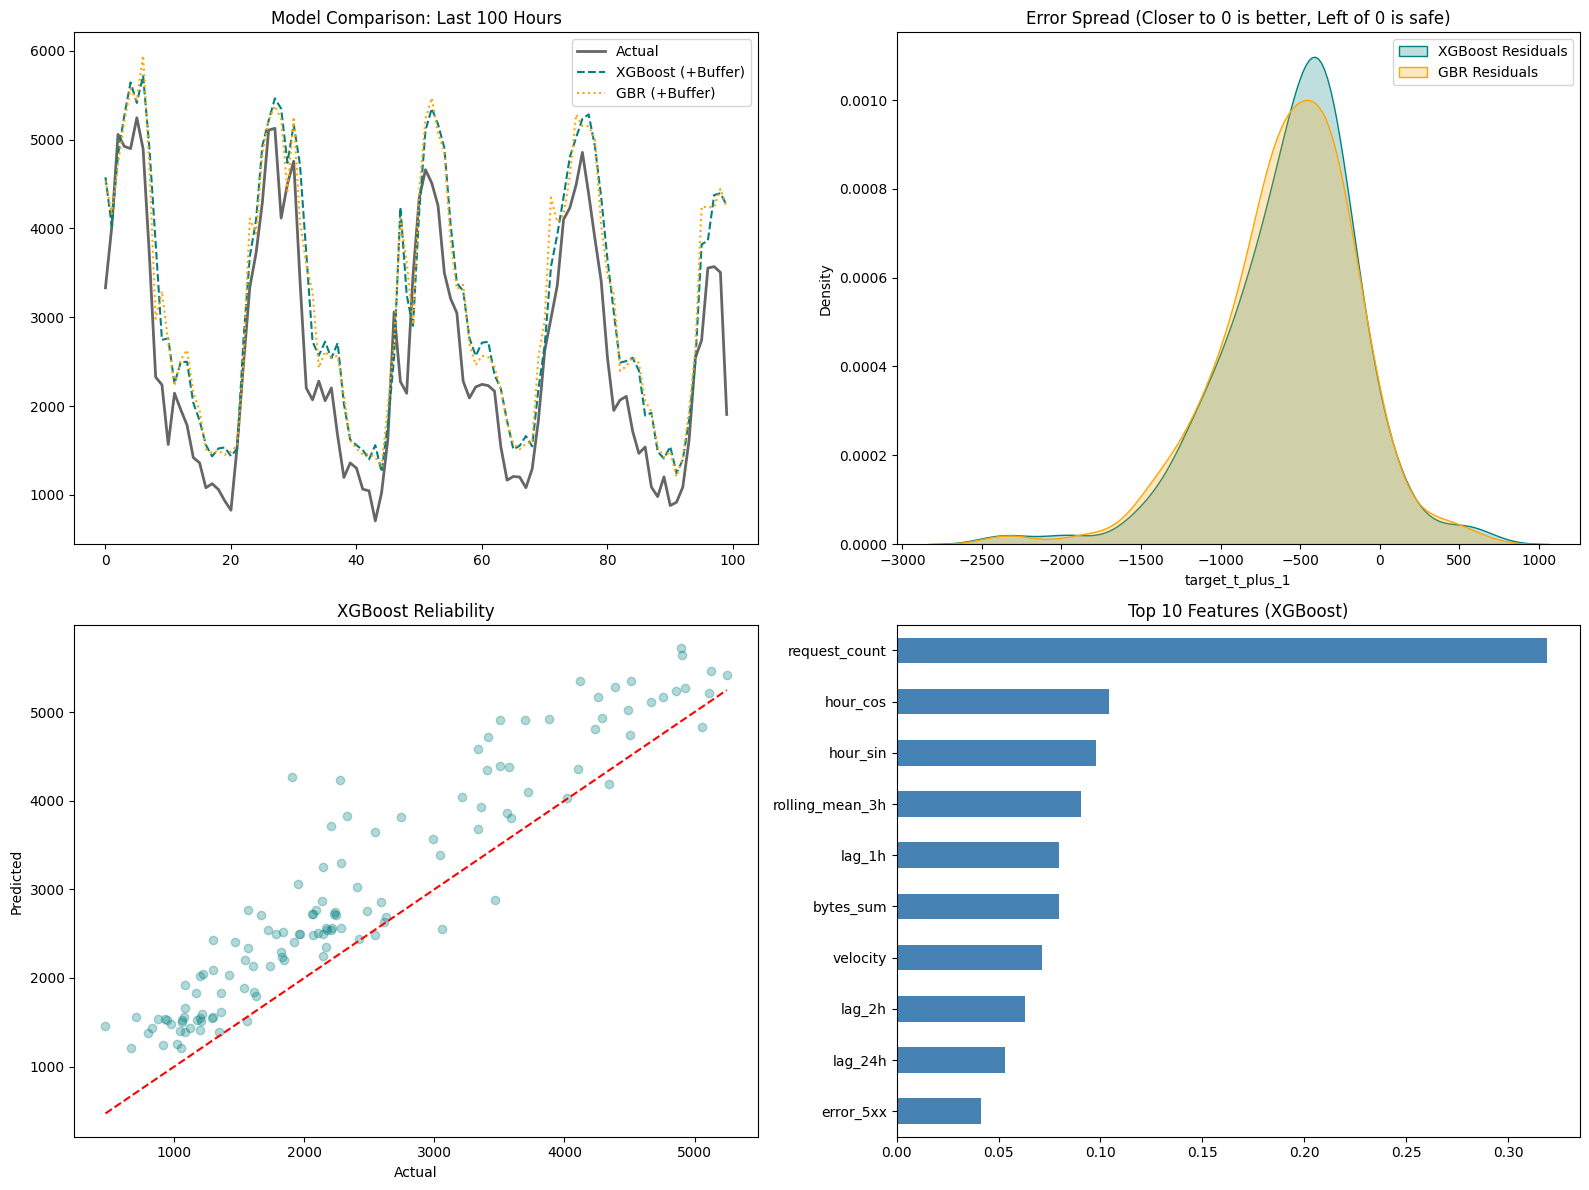


--- PERFORMANCE TOURNAMENT ---
                     MAE    RMSE  R2_Score  MAPE_%  Under_Predict_Rate  Avg_Under_Error
XGBoost_Advanced  583.91  702.27    0.6859   32.17              0.0469           260.39
GBR_Advanced      598.76  715.83    0.6736   32.99              0.0469           229.59


In [25]:
best_xgb, best_gbr = run_tuned_comparison(hourly_df)